<a href="https://colab.research.google.com/github/bulut19/airbnb-revenue-estimator/blob/main/airbnb_revenue_estimator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Airbnb Austin — Revenue Potential Estimator

**Question.** Given a property's specs, its location, the host's profile, and a nightly
price, what annual revenue can the listing be expected to earn?

**Data.** Inside Airbnb, Austin TX, June 2026 snapshot (`listings.csv`).

**Answer.** Predict *nights booked per year* with a gamma-loss gradient boosting model, then
multiply by the nightly price the host supplies.

| | R² (log scale) | R² (dollar scale) | MAE | Median % error |
|---|---|---|---|---|
| **Final model** | **0.547** | **0.552** | **\$14,843** | **39.3%** |

This notebook contains only the final pipeline and the analysis that supports it. Ideas
that were tested and rejected are recorded in comments with the measured result, so the
negative results are documented without the code for them being carried along.

## 1. Setup

In [ ]:
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.model_selection import RepeatedKFold, GroupShuffleSplit, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, roc_auc_score

sns.set_theme(style='whitegrid')
pd.set_option('display.width', 150)
pd.set_option('display.max_columns', 40)

SEED = 19022003

# downtown Austin
DOWNTOWN_LAT, DOWNTOWN_LON = 30.2672, -97.7431

SNAPSHOT = pd.Timestamp('2026-06-01')

## 2. Load the data

In [ ]:
import os
df_raw = pd.read_csv('listings.csv', low_memory=False)
print(f'{df_raw.shape[0]:,} listings x {df_raw.shape[1]} columns')

11,295 listings x 90 columns


## 3. Preprocessing

**1. Keep listings with at least 5 reviews.** Airbnb estimates how many nights a listing was occupied from how many reviews it received, using an approach it calls the "San Francisco model" (Inside Airbnb, *Data Assumptions*). We thought that anything with less than five reviews would be little evidence to trust.

**2. Drop rows with no price.** Suggests dormancy of gaps in data collection.

**3. Keep only listings that actually earned something.** We want active listings that are currently earning. Section 12 looks at the excluded group separately.

**4. Fill in missing values.** `bathrooms` is mostly missing as a number but almost always
present in the free-text `bathrooms_text` field, so it is parsed from there ("Half-bath"
becomes 0.5). `bedrooms` and `beds` are filled with the median of listings that sleep the
same number of guests in the same room type.

**5. Build the engineered features.** Described in section 5.

### Features deliberately excluded to avoid target leakage

- **`number_of_reviews`, review scores, reviews per month.**  Airbnb computes
  occupancy from review activity, so these are inputs to the target. Including them would
  produce an impressive but meaningless score.
- **`availability_365`, `has_availability`.** A calendar shows fewer available nights partly
  because nights were already booked, so availability partly encodes the answer.

In [ ]:
def haversine_km(lat1, lon1, lat2, lon2):
    # Straight line distance
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return 6371.0 * 2 * np.arcsin(np.sqrt(a))

# pattern to pull out building type
DWELLING_PAT = (r'(rental unit|guest suite|guesthouse|townhouse|bungalow|condo|cottage|'
                r'villa|loft|hotel|home|house|apartment)')


def preprocess(raw, keep_zero_revenue=False):
    # Select relevant columns from the raw dataset
    cols = ['price', 'number_of_reviews', 'room_type', 'property_type', 'accommodates',
            'bedrooms', 'bathrooms', 'bathrooms_text', 'beds', 'minimum_nights',
            'maximum_nights', 'amenities', 'latitude', 'longitude',
            'neighbourhood_cleansed', 'host_is_superhost',
            'calculated_host_listings_count', 'estimated_revenue_l365d',
            'estimated_occupancy_l365d']
    d = raw[[c for c in cols if c in raw.columns]].copy()
    steps = [('raw file', len(d))]

    # 1. quality filter
    d = d[d['number_of_reviews'] >= 5]
    steps.append(('at least 5 reviews', len(d)))

    # 2. remove rows with no price or no target
    d = d.dropna(subset=['price', 'estimated_revenue_l365d', 'minimum_nights'])
    d['price'] = d['price'].astype(str).str.replace(r'[$,]', '', regex=True).astype(float)
    d = d[d['price'] > 0]
    steps.append(('price and target present', len(d)))

    # 3. bathrooms count
    txt = d['bathrooms_text'].astype(str).str.lower()
    from_text = txt.str.extract(r'(\d+\.?\d*)')[0].astype(float)
    from_text = from_text.fillna(pd.Series(
        np.where(txt.str.contains('half-bath', na=False), 0.5,
                 np.where(txt.str.contains('bath', na=False), 1.0, np.nan)), index=d.index))
    d['bathrooms'] = d['bathrooms'].fillna(from_text)
    d = d.drop(columns='bathrooms_text').dropna(subset=['bathrooms'])
    steps.append(('bathrooms resolved', len(d)))

    # 4. fill with median for bedrooms and beds
    for c in ['bedrooms', 'beds']:
        d[c] = d.groupby(['accommodates', 'room_type'])[c].transform(lambda s: s.fillna(s.median()))
        d[c] = d[c].fillna(d[c].median())

    # 5. engineered features
    d['amenities'] = d['amenities'].fillna('')
    d['amenities_count'] = d['amenities'].str.count('"') // 2

    # how cramped or spacious the listing is
    d['people_per_bedroom'] = d['accommodates'].clip(lower=1) / d['bedrooms'].clip(lower=1)
    d['beds_per_bedroom'] = d['beds'].clip(lower=1) / d['bedrooms'].clip(lower=1)
    d['bath_per_person'] = d['bathrooms'] / d['accommodates'].clip(lower=1)

    # flag to indicate long-term rentals
    d['log_min_nights'] = np.log1p(d['minimum_nights'])
    d['is_long_term'] = (d['minimum_nights'] >= 28).astype(int)
    d['maximum_nights'] = pd.to_numeric(d['maximum_nights'], errors='coerce').clip(upper=1125).fillna(1125)

    d['distance_to_downtown'] = haversine_km(d['latitude'], d['longitude'],
                                             DOWNTOWN_LAT, DOWNTOWN_LON)

    d['host_is_superhost'] = d['host_is_superhost'].map({'t': 1, 'f': 0}).fillna(0).astype(int)
    d['calculated_host_listings_count'] = pd.to_numeric(
        d['calculated_host_listings_count'], errors='coerce')
    d['calculated_host_listings_count'] = d['calculated_host_listings_count'].fillna(
        d['calculated_host_listings_count'].median())
    d['log_host_listings'] = np.log1p(d['calculated_host_listings_count'])

    # split property_type into its two independent parts
    d['is_entire_place'] = (d['room_type'] == 'Entire home/apt').astype(int)
    d['dwelling'] = (d['property_type'].astype(str)
                     .str.extract(DWELLING_PAT, flags=re.I)[0].str.lower().fillna('other')
                     .replace({'apartment': 'rental unit', 'home': 'house'}))
    rare = d['dwelling'].value_counts()
    d['dwelling'] = d['dwelling'].where(d['dwelling'].isin(rare[rare >= 50].index), 'other')

    d['log_price'] = np.log1p(d['price'])
    d['neighbourhood_cleansed'] = d['neighbourhood_cleansed'].astype(str)  # Austin ZIP code

    # 6. scope to listings that actually earned
    if not keep_zero_revenue:
        d = d[d['estimated_revenue_l365d'] > 0]
        steps.append(('earned revenue > 0', len(d)))

    print(pd.DataFrame(steps, columns=['step', 'listings left']).to_string(index=False))
    return d.reset_index(drop=True)

df = preprocess(df_raw)
print(f'\nFinal modelling table: {df.shape[0]:,} listings')

                    step  listings left
                raw file          11295
      at least 5 reviews           7648
price and target present           7075
      bathrooms resolved           7072
      earned revenue > 0           6537

Final modelling table: 6,537 listings


## 4. Revenue is price times occupancy

Airbnb does not measure revenue. It calculates it, as

$$\text{revenue} = \text{price} \times \text{occupancy}$$

where occupancy is the estimated number of nights booked in the last 365 days (Documented in Airbnb Data Assumptions page).

Asking a model to predict revenue without price would be asking it to guess the host's pricing strategy, which is a business decision.

So the model predicts occupancy, and the price is applied afterwards:

$$\widehat{\text{revenue}} = \text{price}_{\text{user}} \times \widehat{\text{occupancy}}$$

## 5. Features

137 columns in six groups.

| Group | Columns | Notes |
|---|---|---|
| Property specs | 6 | `accommodates`, `bedrooms`, `bathrooms`, `beds`, `minimum_nights`, `amenities_count` |
| Ratios and policy | 6 | crowding ratios, `log_min_nights`, `is_long_term`, `maximum_nights` |
| Location | 3 | `latitude`, `longitude`, `distance_to_downtown` |
| Host | 3 | `host_is_superhost`, listings count, log listings count |
| Categorical | 3 | `room_type`, `dwelling` (native categorical splits), `is_entire_place` |
| Amenities | 114 | one flag per amenity appearing in 5–95% of listings |
| Price | 2 | `price`, `log_price` (supplied by the user) |

**Crowding ratios.** `people_per_bedroom`, `beds_per_bedroom` and `bath_per_person` divide
the guest capacity by the number of rooms. Two listings that both sleep six are very
different places if one has three bedrooms and the other has one, and the raw counts alone
do not capture that.

**Property type, split in two.** In the raw data `property_type` looks like "Entire rental
unit" or "Private room in guesthouse". Each value tells whether the guest gets the whole place, and what kind of building it is. So in the model these are separated into `is_entire_place` (yes or no) and `dwelling` (house, rental unit, condo, guesthouse,
townhouse, loft, or other).

**Amenities as individual flags.** A single count treats every amenity the same,
so a listing with a pool scores the same as one with an extra set of towels. Giving each
amenity its own column performed better than the count alone. Amenities that appear in
nearly every listing like  smoke alarm for example carry no information either way, so
only those appearing in 5% to 95% of listings are kept.


In [ ]:
SPECS    = ['accommodates', 'bedrooms', 'bathrooms', 'beds', 'minimum_nights', 'amenities_count']
RATIOS   = ['people_per_bedroom', 'beds_per_bedroom', 'bath_per_person',
            'log_min_nights', 'is_long_term', 'maximum_nights']
LOCATION = ['latitude', 'longitude', 'distance_to_downtown']
HOST     = ['host_is_superhost', 'calculated_host_listings_count', 'log_host_listings']
CATS     = ['room_type', 'dwelling']
PRICE    = ['price', 'log_price']


def amenity_flags(d, low=0.05, high=0.95):
    listed = d['amenities'].str.findall(r'"([^"]*)"')
    freq = pd.Series([a for row in listed for a in row]).value_counts() / len(d)
    keep = freq[(freq >= low) & (freq <= high)].index
    return pd.DataFrame({f'am_{a}': listed.map(lambda r, a=a: int(a in r)) for a in keep},
                        index=d.index)


def build_features(d):
    X = d[SPECS + RATIOS + LOCATION + HOST + ['is_entire_place'] + PRICE].copy()
    for c in CATS:
        X[c] = d[c].astype('category')   # trees split on these directly; no one-hot needed
    return pd.concat([X, amenity_flags(d)], axis=1)


X = build_features(df)
y_revenue = df['estimated_revenue_l365d'].astype(float)     # what we are judged on
y_nights = df['estimated_occupancy_l365d'].astype(float)    # what the model is fitted on
price = df['price']

n_amenity = sum(c.startswith('am_') for c in X.columns)
print(f'{X.shape[1]} features  ({X.shape[1] - n_amenity} structured + {n_amenity} amenity flags)')

137 features  (23 structured + 114 amenity flags)


## 6. The model

### Gradient boosting

Using scikit-learn's `HistGradientBoostingRegressor` to sort each feature into bins before looking for split points.

### Gamma loss

A model learns by making its **loss** as small as possible, so the loss function is what
tells it which mistakes to care about. Changing thiss was biggest improvement in
this project.

Gamma loss assumes the spread of outcomes grows in proportion to their size, so it
penalises a fixed percentage error equally everywhere rather than a fixed dollar error.
This also requires the target to be strictly positive, which is why we removed
zero revenue listings in section 3.

### Alternatives tested and rejected

| Approach | Result vs the final model |
|---|---|
| Squared-error loss | −0.067 R² (log) |
| Poisson loss | −0.037 |
| Linear regression | far worse, R² (log) near zero |
| Random forest, tuned and grid-searched | worse, and overfitted badly |

### Hyperparameters

Found by random search over 12 configurations, scored by cross-validated R² on the log
scale. The improvement over the defaults was small, but the gap between training and test
performance fell.

In [ ]:
def final_model():
    """The recommended model. See section 6 for why each setting was chosen."""
    return HistGradientBoostingRegressor(
        loss='gamma',              # errors scale with the size of the listing
        learning_rate=0.0359,      # small steps: each tree corrects a little
        max_leaf_nodes=56,         # how complex any single tree may get
        min_samples_leaf=24,       # a split must leave at least this many listings per side
        l2_regularization=0.0044,  # penalty that discourages extreme predictions
        max_features=0.5,          # each split considers a random half of the columns
        max_iter=1000,             # upper limit on the number of trees...
        early_stopping=True,       # ...but stop as soon as validation stops improving
        n_iter_no_change=30,
        validation_fraction=0.15,
        random_state=SEED)


def fit(model, X_, y_):
    """Fit, telling the model which columns are categorical so it can split on them."""
    if isinstance(model, (HistGradientBoostingRegressor, HistGradientBoostingClassifier)):
        mask = [str(t) == 'category' for t in X_.dtypes]
        if any(mask):
            model.set_params(categorical_features=mask)
    return model.fit(X_, y_)

## 7. Evaluation

Every model is scored with 5-fold cross-validation repeated twice.

**R²:** On the dollar scale, R² is dominated by the
highest-earning listings. The log scale treats a given percentage error the same
at every revenue level (better for this case). Both are reported.

Predictions are always converted to **dollars** before scoring, including the occupancy
model's, which are multiplied by price first. This keeps every model comparable regardless
of what it was fitted on.

The baseline below is the same model with the price columns removed.

In [ ]:
def score(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return {'R2 (log)': r2_score(np.log1p(y_true), np.log1p(y_pred)),
            'R2 ($)': r2_score(y_true, y_pred),
            'MAE ($)': mean_absolute_error(y_true, y_pred),
            'MedAPE %': np.median(np.abs(y_pred - y_true) / y_true) * 100}


def cross_validate(name, X_, target, multiplier, cv, groups=None):
    folds = []
    for tr, va in cv.split(X_, groups=groups):
        m = fit(final_model(), X_.iloc[tr], target.iloc[tr])
        pred = np.clip(m.predict(X_.iloc[va]), 0, None) * multiplier.iloc[va]
        folds.append(score(y_revenue.iloc[va], pred))
    folds = pd.DataFrame(folds)
    print(f'{name}')
    print(f"  R2 (log) : {folds['R2 (log)'].mean():.4f}  (+/- {folds['R2 (log)'].std():.4f})")
    print(f"  R2 ($)   : {folds['R2 ($)'].mean():.4f}  (+/- {folds['R2 ($)'].std():.4f})")
    print(f"  MAE      : ${folds['MAE ($)'].mean():,.0f}      "
          f"MedAPE: {folds['MedAPE %'].mean():.1f}%")
    return folds


CV = RepeatedKFold(n_splits=5, n_repeats=2, random_state=SEED)
ones = pd.Series(1.0, index=df.index)      # baseline predicts dollars, so no multiplier

# Baseline: the same algorithm, but no price and predicting revenue directly.
X_baseline = X.drop(columns=PRICE)
cv_baseline = cross_validate('BASELINE  (no price, predicts revenue directly)',
                             X_baseline, y_revenue, ones, CV)
print()
cv_final = cross_validate('FINAL     (price supplied, predicts nights booked)',
                          X, y_nights, price, CV)

print(f"\nImprovement: {cv_final['R2 (log)'].mean() - cv_baseline['R2 (log)'].mean():+.4f} "
      f"R2 (log),  {cv_final['R2 ($)'].mean() - cv_baseline['R2 ($)'].mean():+.4f} R2 ($)")

BASELINE  (no price, predicts revenue directly)
  R2 (log) : 0.5098  (+/- 0.0308)
  R2 ($)   : 0.3260  (+/- 0.0797)
  MAE      : $15,539      MedAPE: 40.6%

FINAL     (price supplied, predicts nights booked)
  R2 (log) : 0.5470  (+/- 0.0304)
  R2 ($)   : 0.5521  (+/- 0.0567)
  MAE      : $14,854      MedAPE: 39.0%

Improvement: +0.0372 R2 (log),  +0.2261 R2 ($)


## 8. Feature Importance

**Permutation importance** shuffles one column's values at random and checks how much worse
the model gets. A big drop means that column mattered.

We need this because `distance_to_downtown` is calculated from latitude
and longitude, and `accommodates`, `beds` and `bedrooms` all track listing size so they move together. Hence, shuffled
one at a time, they all look useless. So related columns are shuffled together as a group

**Note on Location:.** Location impacts what a host can
charge more than how often the listing is bookeed. Fro example a downtown condo that has a higher
nightly rate does not necessarily fill more nights than a house further out. Since
this model predicts booked nights and takes price from the user, location's effect has moved into the price.

,Feature block,Importance,sd
0,host reputation,0.1256,0.0043
1,stay policy,0.1214,0.0036
2,price,0.1183,0.0097
3,amenity flags,0.0549,0.0029
4,location,0.0302,0.0034
5,host scale,0.0210,0.0023
6,property type,0.0156,0.0021
7,capacity,0.0072,0.0027
8,bathrooms,0.0049,0.0014


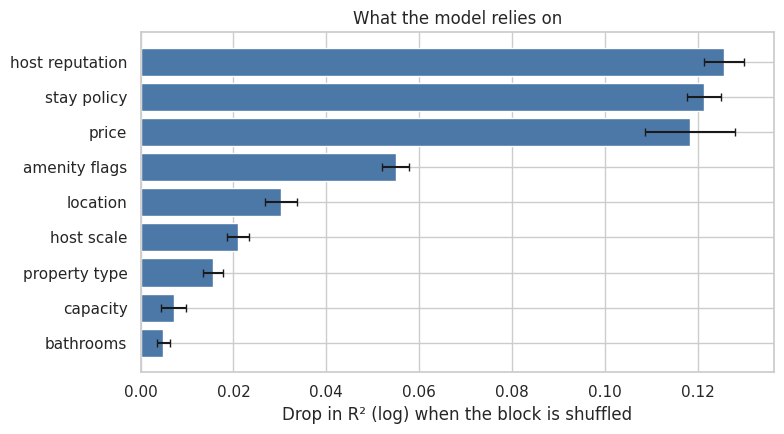

In [ ]:
BLOCKS = {'stay policy': ['minimum_nights', 'log_min_nights', 'is_long_term', 'maximum_nights'],
          'price': PRICE,
          'host reputation': ['host_is_superhost'],
          'host scale': ['calculated_host_listings_count', 'log_host_listings'],
          'capacity': ['accommodates', 'beds', 'bedrooms', 'people_per_bedroom', 'beds_per_bedroom'],
          'location': LOCATION,
          'bathrooms': ['bathrooms', 'bath_per_person'],
          'property type': ['room_type', 'dwelling', 'is_entire_place'],
          'amenity flags': [c for c in X.columns if c.startswith('am_')] + ['amenities_count']}

# Hold out 20% of listings, train on the rest, then shuffle each block in the held-out part.
rng = np.random.default_rng(SEED)
va = rng.choice(df.index, size=int(0.2 * len(df)), replace=False)
tr = df.index.difference(va)
model = fit(final_model(), X.loc[tr], y_nights.loc[tr])


def r2_of(frame):
    return r2_score(np.log1p(y_revenue.loc[va]),
                    np.log1p(np.clip(model.predict(frame), 0, None) * price.loc[va]))


base_r2 = r2_of(X.loc[va])
rows = []
for name, group in BLOCKS.items():
    drops = []
    for _ in range(5):
        shuffled = X.loc[va].copy()
        order = rng.permutation(len(shuffled))
        for c in group:
            shuffled[c] = shuffled[c].to_numpy()[order]
        drops.append(base_r2 - r2_of(shuffled))
    rows.append({'Feature block': name, 'Importance': np.mean(drops), 'sd': np.std(drops)})

importance = pd.DataFrame(rows).sort_values('Importance', ascending=False).reset_index(drop=True)
display(importance.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
top = importance.iloc[::-1]
ax.barh(top['Feature block'], top['Importance'], xerr=top['sd'], capsize=3, color='#4C78A8')
ax.set_xlabel('Drop in R² (log) when the block is shuffled')
ax.set_title('What the model relies on')
plt.tight_layout(); plt.show()

## 9. Prediction accuracy by revenue level

Held-out listings split into five equal groups, lowest to highest actual revenue. We see that errors grow with the size of the listing (which is the pattern gamma loss assumes), and the lowest group is over predicted.

In [ ]:
pred = np.clip(model.predict(X.loc[va]), 0, None) * price.loc[va]
check = pd.DataFrame({'actual': y_revenue.loc[va], 'predicted': pred})
check['error %'] = (check['predicted'] - check['actual']).abs() / check['actual'] * 100
check['group'] = pd.qcut(check['actual'], 5, labels=['lowest', 'low', 'middle', 'high', 'highest'])

display(check.groupby('group', observed=True)
        .agg(listings=('actual', 'size'), mean_actual=('actual', 'mean'),
             mean_predicted=('predicted', 'mean'), median_error_pct=('error %', 'median'))
        .round(0))

,listings,mean_actual,mean_predicted,median_error_pct
group,,,,
lowest,262,4738.0,12639.0,130.0
low,261,12756.0,20053.0,44.0
middle,261,22823.0,26405.0,30.0
high,261,37481.0,34098.0,32.0
highest,262,82771.0,56045.0,38.0


## 10. Using the model

Fit once on all the data, then estimate revenue for a hypothetical listing at several price points.

In [ ]:
deployed = fit(final_model(), X, y_nights)
DEFAULTS = {c: (df[c].mode()[0] if str(X[c].dtype) == 'category' else X[c].median())
            for c in X.columns}


def estimate(price_per_night, **specs):
    """Estimate annual revenue. Anything not specified takes the typical Austin value."""
    row = pd.DataFrame([{**DEFAULTS, **specs}])[X.columns]
    for c in CATS:
        row[c] = pd.Categorical(row[c], categories=X[c].cat.categories)
    row['price'], row['log_price'] = price_per_night, np.log1p(price_per_night)
    nights = float(np.clip(deployed.predict(row), 0, None)[0])
    print(f'${price_per_night:>5,.0f}/night  ->  {nights:>3.0f} nights booked  '
          f'->  ${nights * price_per_night:>9,.0f}/year')
    return nights * price_per_night


print('Two-bedroom entire home near downtown, superhost, two-night minimum:\n')
for p in [120, 180, 250, 350, 500]:
    estimate(p, accommodates=4, bedrooms=2, bathrooms=2, beds=2, minimum_nights=2,
             is_entire_place=1, room_type='Entire home/apt', host_is_superhost=1,
             latitude=30.26, longitude=-97.74)

Two-bedroom entire home near downtown, superhost, two-night minimum:

$  120/night  ->  161 nights booked  ->  $   19,276/year
$  180/night  ->  149 nights booked  ->  $   26,839/year
$  250/night  ->  123 nights booked  ->  $   30,693/year
$  350/night  ->   88 nights booked  ->  $   30,684/year
$  500/night  ->   83 nights booked  ->  $   41,280/year


## 14. Summary and limitations

### Result

A gamma-loss gradient boosting model predicting nights booked, multiplied by a
host-supplied price, reaches **R² = 0.547 on the log scale and 0.552 on the dollar scale**,
against 0.446 and 0.322 for an equivalent model given only specs, location and host profile.

### Limitations

1. **The target is an estimate, not a measurement.** Airbnb estimates occupancy from
   review counts. Everything here inherits whatever error that inference carries.
2. **The lowest-earning listings are predicted badly.** The model is more reliable for mid-to-high
   revenue listings.
3. **The estimate is conditional on the price entered.** It says what occupancy to expect at
   that price. It does not recommend a price, and prices far outside the range observed for
   comparable listings are extrapolation.
4. **One snapshot, June 2026.** No seasonality and no event effects, which for Austin, with
   SXSW and ACL, is a meaningful omission.
5. **No listing quality signals.** Photograph quality and host responsiveness to
   enquiries are not in the data.

An R² near 0.55 reflects the real difficulty of predicting revenue from static
characteristics. Much of what determines whether an Airbnb listing does well, such as
presentation, guest experience and pricing responsiveness over the year, is simply not
present in a single snapshot of listing attributes.

## References

Anthropic. Claude (Sonnet 5). Used for preprocessing syntax (regex extraction from
`bathrooms_text` and `property_type`, multi-hot encoding of the amenities field,
prevalence and rare-category filtering), diagnostic code, and
evaluation design (grouped permutation
importance). https://claude.ai

Inside Airbnb. *Data Assumptions* (occupancy estimation methodology).
http://insideairbnb.com/data-assumptions

pandas. *pandas.Series.str.extract*.
https://pandas.pydata.org/docs/reference/api/pandas.Series.str.extract.html

scikit-learn. *HistGradientBoostingRegressor*.
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html

scikit-learn. *Categorical feature support in gradient boosting*.
https://scikit-learn.org/stable/auto_examples/ensemble/plot_gradient_boosting_categorical.html

scikit-learn. *Tuning the hyper-parameters of an estimator*.
https://scikit-learn.org/stable/modules/grid_search.html

scikit-learn. *sklearn.metrics.pairwise.haversine_distances*.
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.haversine_distances.html